# Pan-Tompkins Algorithm for R-Peak Detection




In [1]:
import wfdb
import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt
import os
import glob
import pandas as pd
import time

plt.rcParams['figure.figsize'] = (12, 4)



## 1. Step-by-Step Algorithm Visualization
The Pan-Tompkins algorithm transforms the ECG signal through a series of filters to isolate the QRS energy.



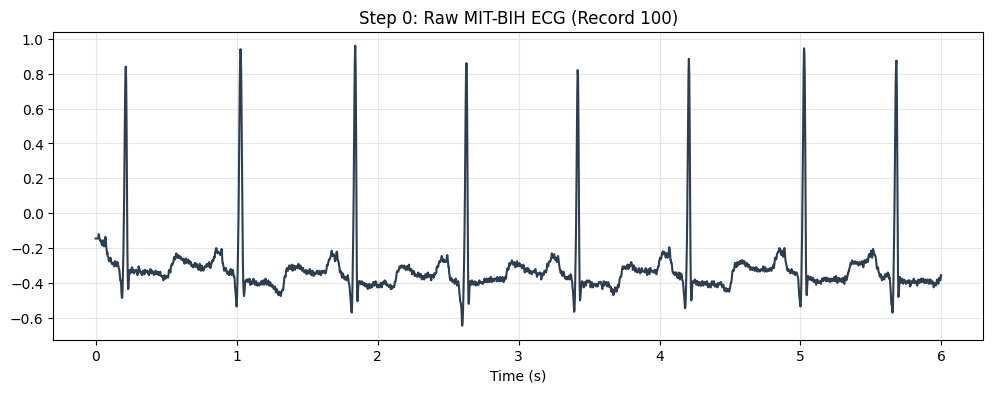

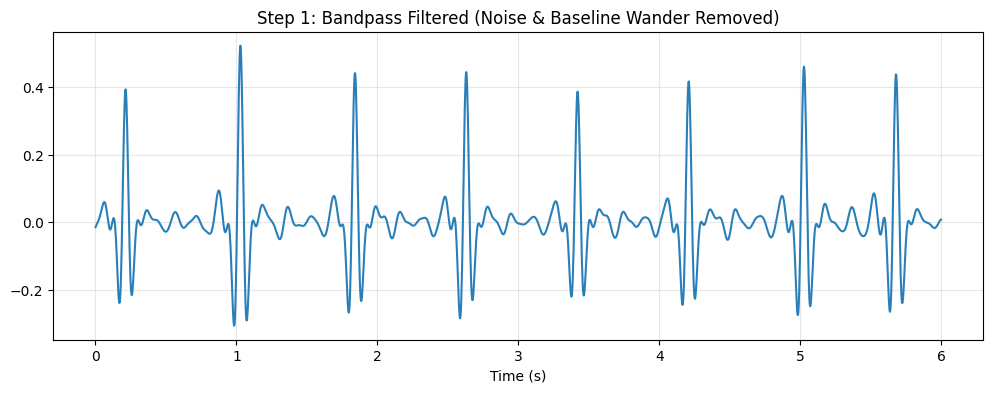

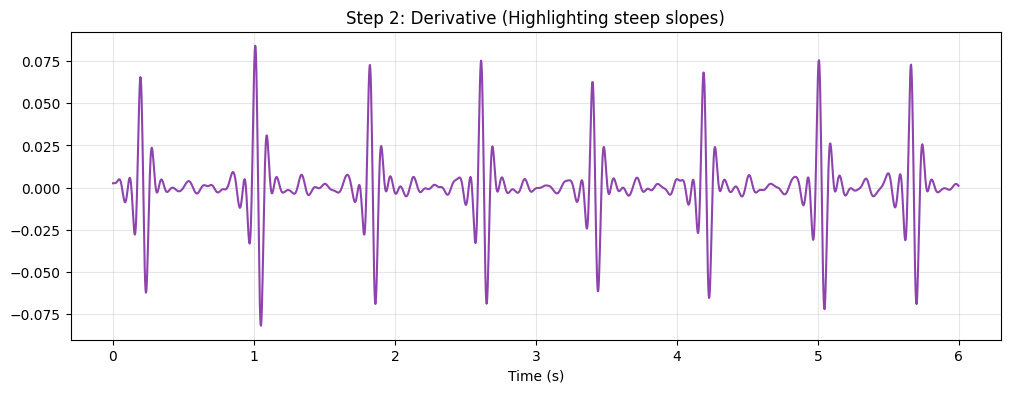

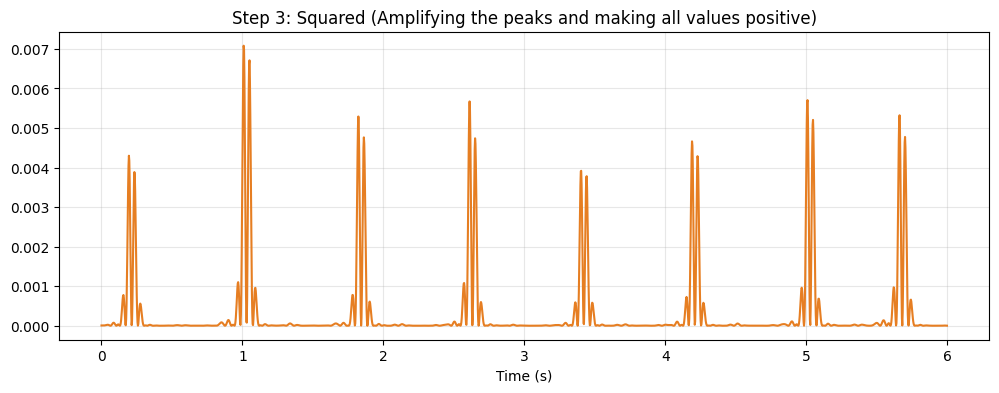

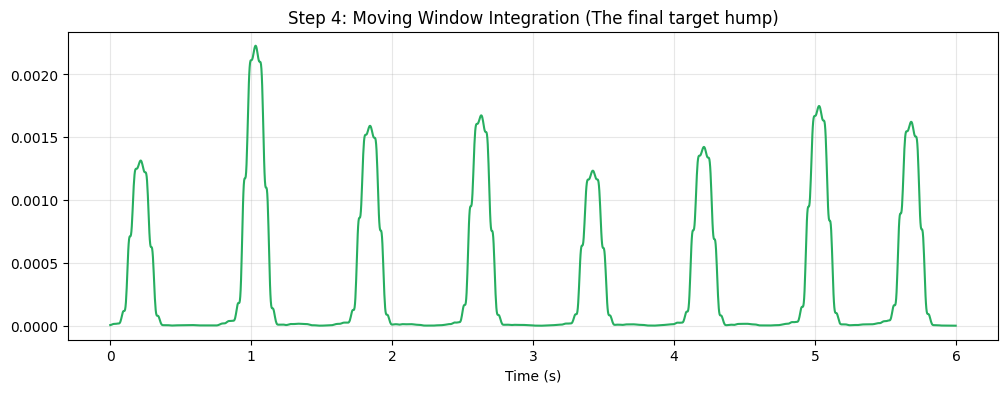

In [2]:
record_name = '100'
fs = 360
seconds = 6
total_samples = fs * seconds

print(f"Downloading MIT-BIH Record {record_name} (first {seconds} seconds)...")
record = wfdb.rdsamp(record_name, sampto=total_samples)

raw_signal = record[0][:, 0] 
t = np.arange(total_samples) / fs

plt.plot(t, raw_signal, color='#2c3e50')
plt.title(f"Step 0: Raw MIT-BIH ECG (Record {record_name})")
plt.xlabel("Time (s)")
plt.grid(True, alpha=0.3)
plt.show()

# Step 1: Bandpass Filter (5-15 Hz)
nyq = 0.5 * fs
b, a = signal.butter(3, [5.0/nyq, 15.0/nyq], btype='band')
filtered_signal = signal.filtfilt(b, a, raw_signal)

plt.plot(t, filtered_signal, color='#2980b9')
plt.title("Step 1: Bandpass Filtered (Noise & Baseline Wander Removed)")
plt.xlabel("Time (s)")
plt.grid(True, alpha=0.3)
plt.show()

# Step 2: Derivative
derivative_signal = np.diff(filtered_signal)
derivative_signal = np.insert(derivative_signal, 0, derivative_signal[0])

plt.plot(t, derivative_signal, color='#8e44ad')
plt.title("Step 2: Derivative (Highlighting steep slopes)")
plt.xlabel("Time (s)")
plt.grid(True, alpha=0.3)
plt.show()

# Step 3: Squaring
squared_signal = np.square(derivative_signal)

plt.plot(t, squared_signal, color='#e67e22')
plt.title("Step 3: Squared (Amplifying the peaks and making all values positive)")
plt.xlabel("Time (s)")
plt.grid(True, alpha=0.3)
plt.show()

# Step 4: Moving Window Integration
window_width = int(0.150 * fs) # 150ms window
window = np.ones(window_width) / window_width
integrated_signal = np.convolve(squared_signal, window, mode='same')

plt.plot(t, integrated_signal, color='#27ae60')
plt.title("Step 4: Moving Window Integration (The final target hump)")
plt.xlabel("Time (s)")
plt.grid(True, alpha=0.3)
plt.show()



## 2. Full Algorithm Implementation


In [3]:
def get_annotated_peaks(record_path):
    ann = wfdb.rdann(record_path, 'atr')
    beat_types = ['N', 'L', 'R', 'B', 'A', 'a', 'J', 'S', 'V', 'r', 'F', 'e', 'j', 'n', 'E', '/', 'f', 'Q', '?']
    beats = [ann.sample[i] for i in range(len(ann.symbol)) if ann.symbol[i] in beat_types]
    return np.array(beats)

def evaluate_peaks(detected_peaks, annotated_peaks, fs, tolerance_ms=150):
    tolerance = int(tolerance_ms / 1000.0 * fs)
    tp = 0; fn = 0
    detected_matched = set()
    for ann in annotated_peaks:
        close_peaks = [p for p in detected_peaks if abs(p - ann) <= tolerance]
        if close_peaks:
            closest = min(close_peaks, key=lambda x: abs(x - ann))
            if closest not in detected_matched:
                tp += 1
                detected_matched.add(closest)
            else:
                fn += 1
        else:
            fn += 1
    fp = len(detected_peaks) - len(detected_matched)
    return tp, fp, fn

def apply_adaptive_threshold(energy, ecg, fs):
    """Applies moving average and adaptive thresholding to find R-peaks."""
    window_size = int(0.10 * fs)
    smoothed = np.convolve(energy, np.ones(window_size) / window_size, mode='same')
    
    min_distance = int(0.20 * fs) 
    candidate_peaks, _ = signal.find_peaks(smoothed, distance=min_distance)
    
    if len(smoothed) > 2*fs:
        spk = np.max(smoothed[:2*fs])
        npk = np.mean(smoothed[:2*fs])
    else:
        spk = np.max(smoothed)
        npk = np.mean(smoothed)
        
    threshold1 = npk + 0.25 * (spk - npk)
    r_peaks = []
    
    for peak in candidate_peaks:
        peak_val = smoothed[peak]
        if peak_val > threshold1:
            spk = 0.125 * peak_val + 0.875 * spk
            r_peaks.append(peak)
        else:
            npk = 0.125 * peak_val + 0.875 * npk
        threshold1 = npk + 0.25 * (spk - npk)
        
    search_radius = int(0.10 * fs)
    refined_peaks = []
    for p in r_peaks:
        start = max(0, p - search_radius)
        end = min(len(ecg), p + search_radius)
        if start < end:
            local_max = np.argmax(np.abs(ecg[start:end]))
            refined_peaks.append(start + local_max)
    return np.array(sorted(set(refined_peaks)))

def detect_r_peaks_pan_tompkins(ecg, fs):
    nyq = 0.5 * fs
    b, a = signal.butter(3, [5.0/nyq, 15.0/nyq], btype='band')
    filtered_signal = signal.filtfilt(b, a, ecg)
    
    derivative_signal = np.diff(filtered_signal)
    derivative_signal = np.insert(derivative_signal, 0, derivative_signal[0])
    
    squared_signal = np.square(derivative_signal)
    
    window_width = int(0.150 * fs) 
    window = np.ones(window_width) / window_width
    integrated_signal = np.convolve(squared_signal, window, mode='same')
    
    # Send the final integrated energy to the adaptive thresholding algorithm
    return apply_adaptive_threshold(integrated_signal, ecg, fs)



## 3. Evaluation on the Full MIT-BIH Database


In [4]:
records = [os.path.basename(f).split('.')[0] for f in glob.glob('*.dat')]
records.sort()

results_pt = []

print(f"Starting evaluation of Pan-Tompkins on {len(records)} records...")

for rec in records:
    try:
        record_path = rec
        record = wfdb.rdsamp(record_path)
        ecg = record[0][:, 0]
        fs = record[1]['fs']
        ann_peaks = get_annotated_peaks(record_path)
        
        t0 = time.time()
        det_pt = detect_r_peaks_pan_tompkins(ecg, fs)
        time_pt = time.time() - t0
        
        tp, fp, fn = evaluate_peaks(det_pt, ann_peaks, fs)
        results_pt.append({'Record': rec, 'Total Beats': len(ann_peaks), 'TP': tp, 'FP': fp, 'FN': fn, 'Time (s)': time_pt})
        
    except Exception as e:
        pass

print("Evaluation completed.")



Starting evaluation of Pan-Tompkins on 45 records...
Evaluation completed.


## 4. Final Metrics


In [5]:
df_pt = pd.DataFrame(results_pt)

df_pt['Sensitivity (%)'] = (df_pt['TP'] / (df_pt['TP'] + df_pt['FN']) * 100).fillna(0)
df_pt['Predictivity (%)'] = (df_pt['TP'] / (df_pt['TP'] + df_pt['FP']) * 100).fillna(0)
df_pt['Error Rate (%)'] = ((df_pt['FP'] + df_pt['FN']) / df_pt['Total Beats'] * 100).fillna(0)

total_beats = df_pt['Total Beats'].sum()
total_tp = df_pt['TP'].sum()
total_fp = df_pt['FP'].sum()
total_fn = df_pt['FN'].sum()
total_time = df_pt['Time (s)'].sum()

overall_se = total_tp / (total_tp + total_fn) * 100
overall_pp = total_tp / (total_tp + total_fp) * 100
overall_er = (total_fp + total_fn) / total_beats * 100

print("="*50)
print("OVERALL PERFORMANCE: PAN-TOMPKINS")
print("="*50)
print(f"Total Beats Evaluated : {total_beats}")
print(f"True Positives (TP)   : {total_tp}")
print(f"False Positives (FP)  : {total_fp}")
print(f"False Negatives (FN)  : {total_fn}")
print(f"Sensitivity (Se)      : {overall_se:.2f} %")
print(f"Positive Predictivity : {overall_pp:.2f} %")
print(f"Detection Error Rate  : {overall_er:.2f} %")
print(f"Total Inference Time  : {total_time:.2f} seconds")
print(f"Avg Time / Record     : {(total_time/len(df_pt)):.3f} seconds")
print("="*50)

df_pt.to_csv('pt_mitbih_results.csv', index=False)
print("\nResults saved to 'pt_mitbih_results.csv'")
display(df_pt.round(2))



OVERALL PERFORMANCE: PAN-TOMPKINS
Total Beats Evaluated : 102941
True Positives (TP)   : 99025
False Positives (FP)  : 235
False Negatives (FN)  : 3916
Sensitivity (Se)      : 96.20 %
Positive Predictivity : 99.76 %
Detection Error Rate  : 4.03 %
Total Inference Time  : 2.96 seconds
Avg Time / Record     : 0.066 seconds

Results saved to 'pt_mitbih_results.csv'


,Record,Total Beats,TP,FP,FN,Time (s),Sensitivity (%),Predictivity (%),Error Rate (%)
0,100,2273,2273,0,0,0.06,100.00,100.00,0.00
1,101,1865,1864,4,1,0.06,99.95,99.79,0.27
2,103,2084,2078,0,6,0.07,99.71,100.00,0.29
3,105,2572,2553,37,19,0.06,99.26,98.57,2.18
4,106,2027,2013,1,14,0.08,99.31,99.95,0.74
5,108,1763,1756,80,7,0.06,99.60,95.64,4.93
6,109,2532,2527,0,5,0.07,99.80,100.00,0.20
7,111,2124,2101,1,23,0.07,98.92,99.95,1.13
8,112,2539,2539,0,0,0.07,100.00,100.00,0.00
9,113,1795,1795,0,0,0.06,100.00,100.00,0.00
